# 🟣 Naive Bayes
---

## 📑 Table of Contents
1. [Introduction & Definition](#1.-Introduction-&-Definition)
2. [How It Works — Math & Intuition](#2.-How-It-Works-—-Math-&-Intuition)
3. [When To Use](#3.-When-To-Use)
4. [Pros & Cons](#4.-Pros-&-Cons)
5. [Dataset Upload & Exploration](#5.-Dataset-Upload-&-Exploration)
   - 5.1 Import Libraries
   - 5.2 Load Dataset
   - 5.3 Exploratory Data Analysis (EDA)
   - 5.4 Preprocessing & Feature Engineering
6. [Training the Model](#6.-Training-the-Model)
   - 6.1 Train/Validation/Test Split
   - 6.2 Fit the Model
7. [Validation](#7.-Validation)
   - 7.1 Cross-Validation
   - 7.2 Validation Metrics
8. [Testing](#8.-Testing)
   - 8.1 Final Test Set Evaluation
   - 8.2 Confusion Matrix & Classification Report
9. [Optimization / Hyperparameter Tuning](#9.-Optimization-/-Hyperparameter-Tuning)
   - 9.1 Pipeline with GridSearchCV
   - 9.2 Best Parameters & Retrain
10. [GaussianNB on Continuous Data (Iris)](#10.-GaussianNB-on-Continuous-Data)
11. [Tips & Tricks Summary](#11.-Tips-&-Tricks-Summary)
12. [Conclusion](#12.-Conclusion)

## 1. Introduction & Definition

**Naive Bayes** is a family of probabilistic classifiers rooted in one of the most foundational theorems of statistics: **Bayes' Theorem**. Despite its seemingly oversimplified 'naive' assumption of conditional feature independence, Naive Bayes has proven to be a remarkably effective, computationally efficient, and theoretically grounded algorithm that excels in domains where other algorithms struggle — most notably in **text classification** and **real-time prediction systems**.

### Bayes' Theorem
At its core, Bayes' Theorem provides a way to calculate the probability of a hypothesis (a class $y$) given our prior knowledge and some new evidence (features $X$):

$$ P(y|X) = \frac{P(X|y) \times P(y)}{P(X)} $$

Where:
- $P(y|X)$ is the **posterior probability** (probability of class $y$ given features $X$).
- $P(X|y)$ is the **likelihood** (probability of features $X$ given class $y$).
- $P(y)$ is the **prior probability** (our initial belief about the frequency of class $y$).
- $P(X)$ is the **evidence** (total probability of observing features $X$).

### The Naive Assumption
In practice, calculating the exact likelihood $P(X|y) = P(x_1, x_2, \dots, x_n|y)$ is computationally intractable because it requires modeling the joint probability of all features simultaneously. To make this feasible, Naive Bayes makes a strong, 'naive' assumption: **all features are conditionally independent of each other given the class label**.

$$ P(X|y) = \prod_{i=1}^{n} P(x_i|y) $$

### Full Classifier
By substituting the naive assumption back into Bayes' Theorem and ignoring the denominator $P(X)$ (since it's the same for all classes and doesn't change the relative rankings), we get the full Naive Bayes classifier. To make a prediction $\hat{y}$, we simply choose the class $y$ that maximizes the numerator:

$$ \hat{y} = \arg\max_y P(y) \prod_{i=1}^{n} P(x_i|y) $$

### The Log-Trick (Numerical Stability)
Multiplying many small probabilities $P(x_i|y)$ quickly leads to numerical underflow (the computer rounds the product to zero). To avoid this, we take the natural logarithm of the equation. Since the logarithm is a monotonically increasing function, maximizing the log-probability is strictly equivalent to maximizing the original probability. The product becomes a sum:

$$ \hat{y} = \arg\max_y \left[ \log P(y) + \sum_{i=1}^{n} \log P(x_i|y) \right] $$

### Naive Bayes Variants
The way we calculate the likelihood $P(x_i|y)$ depends on the nature of our features, leading to different variants of Naive Bayes:

1. **GaussianNB**: Used for continuous features. Assumes features follow a normal (Gaussian) distribution within each class:
   $$ P(x_i|y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right) $$
2. **MultinomialNB**: Used for discrete counts (e.g., word counts or TF-IDF scores). The likelihood is proportional to the count of feature $x_i$ in class $y$, plus a smoothing parameter $\alpha$:
   $$ P(x_i|y) \propto count(x_i, y) + \alpha $$
3. **BernoulliNB**: Used for binary/boolean features (e.g., whether a word is present or absent in a document).
4. **ComplementNB**: An adaptation of MultinomialNB designed to handle imbalanced datasets (especially in text classification). It calculates the probability of a word belonging to *all other classes* instead of the target class.

### Laplace (Additive) Smoothing
If a word appears in the test set but was never seen in the training set for a particular class, its probability $P(x_i|y)$ would be 0. Because we multiply (or log-sum) probabilities, a single 0 wipes out all other evidence. **Laplace smoothing** adds a small constant $\alpha$ (typically $\alpha=1$) to every feature count to ensure no probability is exactly zero, enabling robust predictions.

## 2. How It Works — Math & Intuition

### The Spam Filter Analogy
Imagine you are building a spam filter. From your historical data, you know that the word 'FREE' appears 90% of the time in spam emails, but only 5% of the time in legitimate emails. If you receive a new email and it contains the word 'FREE', your prior belief that this email is spam increases dramatically based on this strong evidence.

Naive Bayes simply extends this logic to consider *all* words in the email simultaneously. It calculates the probability of the email being spam given word 1, word 2, etc., and multiplies them all together (naively assuming that the presence of 'FREE' is independent of the presence of 'VIAGRA', given that it's spam).

### Step-by-Step Execution
1. **Training Phase (Priors):** Estimate the prior probabilities $P(y)$ for each class by counting the proportion of each class in the training dataset ($P(y) = count(y)/N$).
2. **Training Phase (Likelihoods):** Estimate the likelihoods $P(x_i|y)$ from the training data. For GaussianNB, compute the mean $\mu$ and variance $\sigma^2$ for each feature per class. For MultinomialNB, count the frequency of each word per class.
3. **Inference Phase (Combine):** For a new sample, look up the likelihood for each of its features. Multiply (or log-sum) these likelihoods together with the class prior.
4. **Normalization (Optional):** To convert these scores into proper probabilities between 0 and 1, normalize them by dividing by the evidence $P(X) = \sum_y P(X|y)P(y)$.
5. **Prediction:** Predict the class with the highest posterior probability (or log-posterior score).

### Worked Example
Let's classify a new document containing the words: `['win', 'money', 'today']`.
- **Classes:** Spam (S), Ham (H)
- **Priors:** $P(S) = 0.4$, $P(H) = 0.6$

**Likelihoods from Training Data:**
- $P(\text{'win'}|S) = 0.2$, $P(\text{'win'}|H) = 0.05$
- $P(\text{'money'}|S) = 0.3$, $P(\text{'money'}|H) = 0.01$
- $P(\text{'today'}|S) = 0.1$, $P(\text{'today'}|H) = 0.1$

**Calculations:**
Score(Spam) = $P(S) \times P(\text{'win'}|S) \times P(\text{'money'}|S) \times P(\text{'today'}|S)$
Score(Spam) = $0.4 \times 0.2 \times 0.3 \times 0.1 = 0.0024$

Score(Ham) = $P(H) \times P(\text{'win'}|H) \times P(\text{'money'}|H) \times P(\text{'today'}|H)$
Score(Ham) = $0.6 \times 0.05 \times 0.01 \times 0.1 = 0.00003$

Since $0.0024 > 0.00003$, the model confidently predicts **Spam**.

## 3. When To Use

- **Text classification**: such as spam filtering, sentiment analysis, and topic categorization.
- **Real-time classification**: because the model is extremely fast to train and inference takes milliseconds.
- **Very small training datasets**: Naive Bayes converges quickly and requires less data to learn the core relationships than complex models.
- **Extremely high-dimensional feature spaces**: such as Bag-of-Words or TF-IDF vectors that often contain 10,000+ features.
- **Multi-class problems**: as it handles any number of classes natively without needing One-Vs-Rest strategies.
- **When you need calibrated probabilities quickly**: Although calibration can be an issue, basic relative probabilities are rapidly obtainable.

## 4. Pros & Cons

| Feature | Pros | Cons |
| :--- | :--- | :--- |
| **Computational Speed** | Extremely fast to train and predict; highly scalable. | The core assumption of feature independence is rarely true in the real world. |
| **Data Requirements** | Performs surprisingly well with very small amounts of training data. | Can be overly confident in its predictions (poor probability calibration). |
| **Dimensionality** | Handles extremely high-dimensional spaces (e.g., 10k+ text features) easily. | Continuous features modeled as Gaussian may not actually be normally distributed. |
| **Multi-class Problems** | Inherently supports multi-class classification natively. | 'Zero Frequency' problem if a category/feature combination is unseen (requires smoothing). |
| **Interpretability** | Easy to extract and inspect the most important features per class. | Less expressive than complex models like Random Forests or Neural Networks. |

## 5. Dataset Upload & Exploration

We use sklearn's **20 Newsgroups dataset** (a subset of 4 categories) for text classification with MultinomialNB, and later the **Iris dataset** for GaussianNB on continuous features.

In [1]:
# ============================================================
# SECTION 5.1 — IMPORT LIBRARIES
# ============================================================

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualizations
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

# Datasets
from sklearn.datasets import fetch_20newsgroups, load_iris

# Preprocessing and Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from collections import Counter

# Naive Bayes Models
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB

# Metrics and Validation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import cross_val_score
from sklearn.calibration import calibration_curve

# Ignore warnings for clean output
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ============================================================
# SECTION 5.2 — LOAD DATASET
# ============================================================

# Select a subset of 4 categories from the 20 Newsgroups dataset
categories = ['sci.space', 'talk.politics.guns', 'rec.sport.hockey', 'comp.graphics']

# Load training and testing data
# We remove headers, footers, and quotes to prevent the model from overfitting to metadata
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, 
                                      remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories, 
                                     remove=('headers', 'footers', 'quotes'))

print(f"Number of categories: {len(newsgroups_train.target_names)}")
print(f"Categories: {newsgroups_train.target_names}")
print(f"Total training samples: {len(newsgroups_train.data)}")
print(f"Total testing samples: {len(newsgroups_test.data)}")

print("--- Sample Document ---")
print(newsgroups_train.data[0][:500], "...")
print(f"--- Category: {newsgroups_train.target_names[newsgroups_train.target[0]]} ---")

Number of categories: 4
Categories: ['comp.graphics', 'rec.sport.hockey', 'sci.space', 'talk.politics.guns']
Total training samples: 2323
Total testing samples: 1546
--- Sample Document ---

Agreed here...I'll never forget Dan Kelly calling the play-by-play in the '87
Canada Cup.  He was masterful!

And Danny Gallivan will _never_ be replaced; even now when I watch HNIC I
remember his voice...when I see an Al MacInnis or Al Iafrate (hey, what's with
these guys named Al who can shoot??) shot from the point I still think
"blistering blast"...THN had a tribute to Gallivan in the issue following his
death; in the story they included a quote from one of the games he did.  It
went: 

"It ...
--- Category: rec.sport.hockey ---


### 💡 TIP for EDA
For text data, the key EDA questions are:
1. **Is the dataset balanced across categories?** Imbalance will bias the prior $P(y)$.
2. **What is the average document length?** Very short documents have fewer features and more uncertainty.
3. **Are there data quality issues** (HTML tags, boilerplate)? The `remove` parameter in `fetch_20newsgroups` handles this by stripping headers, footers, and quotes.

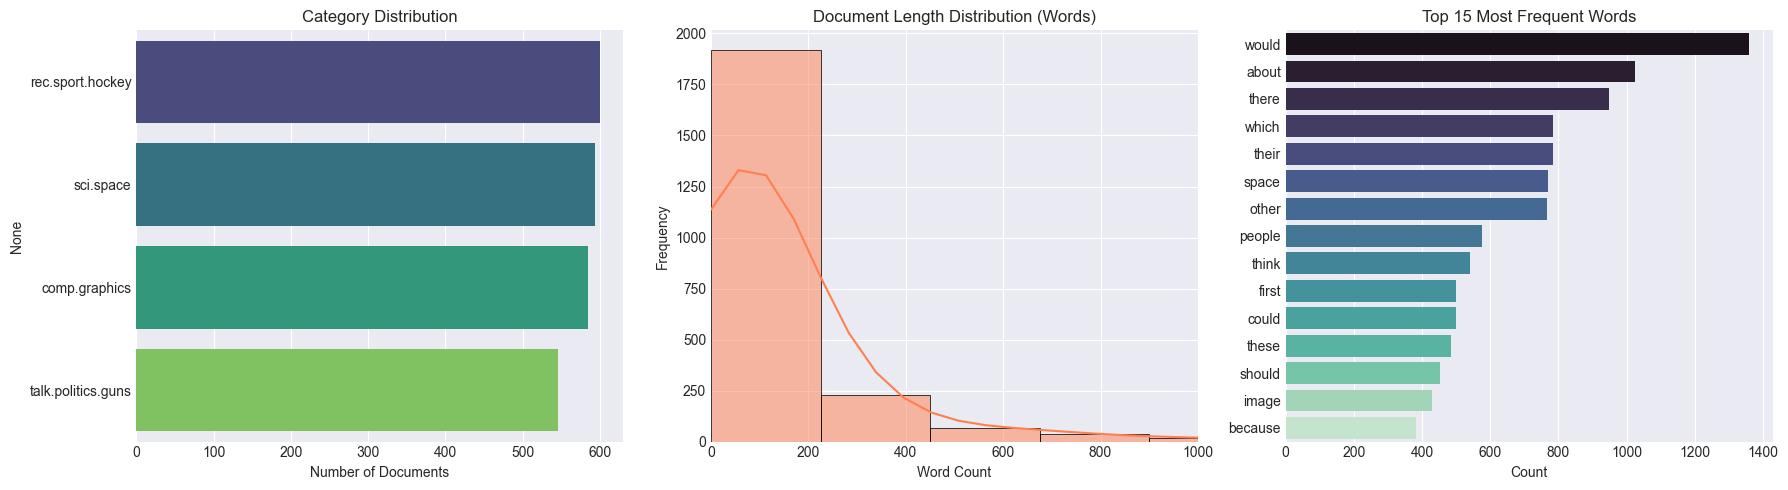

In [3]:
# ============================================================
# SECTION 5.3 — EDA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Category Distribution
category_counts = pd.Series(newsgroups_train.target).map(
    lambda x: newsgroups_train.target_names[x]).value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, ax=axes[0], palette='viridis')
axes[0].set_title('Category Distribution')
axes[0].set_xlabel('Number of Documents')

# Plot 2: Document Length Distribution
doc_lengths = [len(doc.split()) for doc in newsgroups_train.data]
sns.histplot(doc_lengths, bins=50, ax=axes[1], color='coral', kde=True)
axes[1].set_xlim(0, 1000)  # limit x-axis for better visibility
axes[1].set_title('Document Length Distribution (Words)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

# Plot 3: Top 15 Most Frequent Words
all_words = ' '.join(newsgroups_train.data).lower().split()
# Quick naive filtering for better visualization
filtered_words = [word for word in all_words if len(word) > 4 and word.isalpha()]
word_counts = Counter(filtered_words).most_common(15)
words, counts = zip(*word_counts)
sns.barplot(x=list(counts), y=list(words), ax=axes[2], palette='mako')
axes[2].set_title('Top 15 Most Frequent Words')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

### 💡 SECTION 5.4 TIPS: Preprocessing for Text
Naive Bayes does **NOT** require feature scaling. In fact, do NOT scale TF-IDF features — scaling can introduce negative values which MultinomialNB cannot handle (it requires non-negative inputs). The key preprocessing involves:
1. **TF-IDF vectorization** (or CountVectorizer for word counts).
2. **Stop word removal** (removing common words like 'the', 'is', 'at').
3. **N-gram extraction** (capturing phrases like 'machine learning' instead of just individual words).

In [4]:
# ============================================================
# SECTION 5.4 — TF-IDF VECTORIZATION
# ============================================================

# Initialize TF-IDF Vectorizer
# max_features limits the vocabulary to the top 10k terms
# ngram_range=(1,2) includes both unigrams (single words) and bigrams (two-word phrases)
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2))

# Fit and transform the training data
X_train_tfidf = vectorizer.fit_transform(newsgroups_train.data)

# Transform the test data (DO NOT fit again)
X_test_tfidf = vectorizer.transform(newsgroups_test.data)

y_train_text = newsgroups_train.target
y_test_text = newsgroups_test.target

print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"TF-IDF matrix shape (Train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (Test): {X_test_tfidf.shape}")

Vocabulary size: 10000
TF-IDF matrix shape (Train): (2323, 10000)
TF-IDF matrix shape (Test): (1546, 10000)


## 6. Training the Model

In [5]:
# ============================================================
# SECTION 6.1 — TRAIN / VAL / TEST SPLIT (Text)
# ============================================================

# For text data, the train/test split is already provided by fetch_20newsgroups.
# We will create a validation set from the training set.
X_tr_tfidf, X_val_tfidf, y_tr, y_val = train_test_split(
    X_train_tfidf, y_train_text, test_size=0.2, stratify=y_train_text, random_state=42
)

print(f"Training set size: {X_tr_tfidf.shape[0]} samples")
print(f"Validation set size: {X_val_tfidf.shape[0]} samples")
print(f"Test set size: {X_test_tfidf.shape[0]} samples")

Training set size: 1858 samples
Validation set size: 465 samples
Test set size: 1546 samples


### 💡 TIP: Choosing the Right Naive Bayes Variant
- **MultinomialNB**: For word count or TF-IDF features (non-negative). Best for text.
- **BernoulliNB**: For binary features (word present/absent). Better for short documents.
- **GaussianNB**: For continuous real-valued features. Best for tabular data.
- **ComplementNB**: Specifically designed for imbalanced text datasets. Often outperforms MultinomialNB.
- **alpha (smoothing)**: Default=1.0 (Laplace). Smaller \alpha = less smoothing, riskier for rare words.

In [6]:
# ============================================================
# SECTION 6.2 — FIT THE MODEL
# ============================================================

# Initialize and train Multinomial Naive Bayes
mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_tr_tfidf, y_tr)

print("--- Learned Log Priors [log P(y)] ---")
for i, target_name in enumerate(newsgroups_train.target_names):
    print(f"{target_name}: {mnb.class_log_prior_[i]:.4f}")
    
# Extract top 10 discriminative words per category
print("\n--- Top 10 Words per Category ---")
feature_names = np.array(vectorizer.get_feature_names_out())

for i, target_name in enumerate(newsgroups_train.target_names):
    # mnb.feature_log_prob_ contains the log probabilities of features given a class
    top10_indices = np.argsort(mnb.feature_log_prob_[i])[-10:]
    top10_words = feature_names[top10_indices]
    print(f"{target_name}: {', '.join(top10_words)}")

--- Learned Log Priors [log P(y)] ---
comp.graphics: -1.3809
rec.sport.hockey: -1.3535
sci.space: -1.3660
talk.politics.guns: -1.4473

--- Top 10 Words per Category ---
comp.graphics: does, looking, need, program, know, file, files, image, thanks, graphics
rec.sport.hockey: don, year, play, season, nhl, games, players, hockey, team, game
sci.space: earth, think, shuttle, launch, moon, orbit, just, like, nasa, space
talk.politics.guns: right, government, just, fbi, weapons, law, don, guns, people, gun


## 7. Validation

In [7]:
# ============================================================
# SECTION 7.1 — CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "MultinomialNB": MultinomialNB(),
    "ComplementNB": ComplementNB(),
    "BernoulliNB": BernoulliNB()
}

print("--- 5-Fold Cross-Validation Accuracy ---")
for name, model in models.items():
    scores = cross_val_score(model, X_train_tfidf, y_train_text, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"{name:15} : {scores.mean():.4f} ± {scores.std():.4f}")

--- 5-Fold Cross-Validation Accuracy ---
MultinomialNB   : 0.9126 ± 0.0094
ComplementNB    : 0.9148 ± 0.0090
BernoulliNB     : 0.7744 ± 0.0155


In [8]:
# ============================================================
# SECTION 7.2 — VALIDATION SET METRICS
# ============================================================

y_val_pred = mnb.predict(X_val_tfidf)

acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, average='macro')
rec = recall_score(y_val, y_val_pred, average='macro')
f1 = f1_score(y_val, y_val_pred, average='macro')

print(f"Validation Accuracy  : {acc:.4f}")
print(f"Validation Precision : {prec:.4f}")
print(f"Validation Recall    : {rec:.4f}")
print(f"Validation F1-Score  : {f1:.4f}")

Validation Accuracy  : 0.8925
Validation Precision : 0.8952
Validation Recall    : 0.8914
Validation F1-Score  : 0.8918


### 🩺 Explaining Metrics for Text Classification
For multi-class text classification, **macro average** treats all categories equally, regardless of their support size. If categories are imbalanced, **weighted average** is fairer because it accounts for class size. **F1 macro** is generally the standard benchmark for multi-class text classification tasks like this one to ensure minority classes are predicted effectively.

## 8. Testing

--- Final Test Classification Report ---
                    precision    recall  f1-score   support

     comp.graphics       0.90      0.90      0.90       389
  rec.sport.hockey       0.87      0.95      0.91       399
         sci.space       0.89      0.81      0.85       394
talk.politics.guns       0.89      0.88      0.89       364

          accuracy                           0.89      1546
         macro avg       0.89      0.89      0.89      1546
      weighted avg       0.89      0.89      0.89      1546



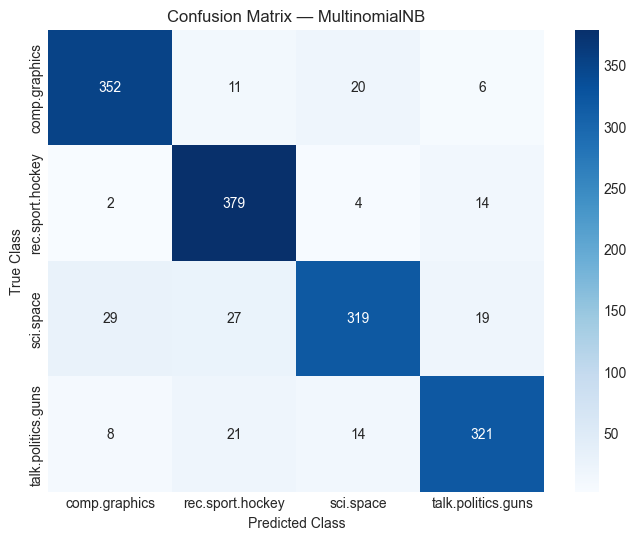

In [9]:
# ============================================================
# SECTION 8.1 & 8.2 — FINAL TEST EVAL & CONFUSION MATRIX
# ============================================================

# Predict on the hold-out test set
y_test_pred = mnb.predict(X_test_tfidf)

print("--- Final Test Classification Report ---")
print(classification_report(y_test_text, y_test_pred, target_names=newsgroups_test.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test_text, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=newsgroups_test.target_names, 
            yticklabels=newsgroups_test.target_names)
plt.title("Confusion Matrix — MultinomialNB")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

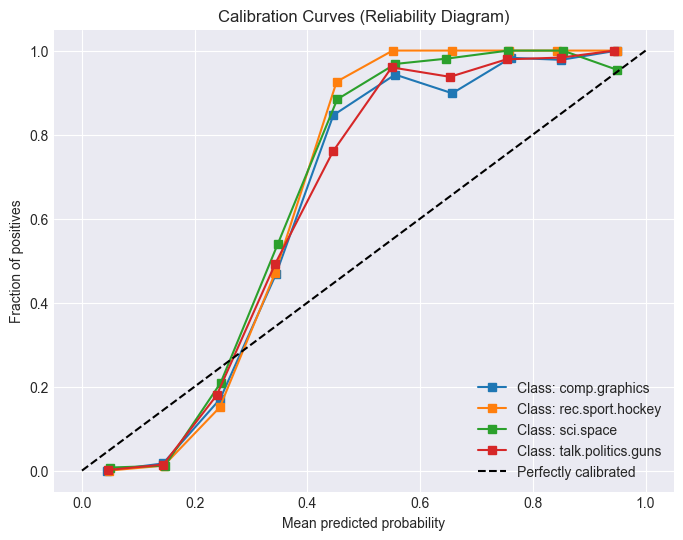

In [10]:
# ============================================================
# SECTION 8.3 — CALIBRATION CURVE
# ============================================================

# Compute probabilities for the test set
y_test_prob = mnb.predict_proba(X_test_tfidf)

plt.figure(figsize=(8, 6))

# Plot calibration curve for each class (One-Vs-Rest approach)
for i, target_name in enumerate(newsgroups_test.target_names):
    # Create binary labels for the current class
    y_test_bin = (y_test_text == i).astype(int)
    prob_pos = y_test_prob[:, i]
    
    fraction_of_positives, mean_predicted_value = calibration_curve(y_test_bin, prob_pos, n_bins=10)
    plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=f"Class: {target_name}")

plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curves (Reliability Diagram)")
plt.legend(loc="lower right")
plt.show()

## 9. Optimization & Hyperparameter Tuning

### 💡 TIP: Using Pipeline for Text ML
In text ML, the TF-IDF vectorizer and the classifier must be treated as a single pipeline to prevent **data leakage** during cross-validation. If you vectorize all text first and then cross-validate, the vectorizer has 'seen' the validation words. sklearn's `Pipeline` makes this seamless and `GridSearchCV` can tune both components simultaneously.

In [11]:
# ============================================================
# SECTION 9.1 — PIPELINE + GRIDSEARCHCV
# ============================================================

# Create a pipeline combining Vectorizer and Classifier
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', MultinomialNB())
])

# Define the hyperparameter grid for both components
param_grid = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
}

# NOTE: We fit the grid search on the raw text data, not the already transformed tfidf matrix
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)

# Fit on the training data (this will take a moment)
grid_search.fit(newsgroups_train.data, y_train_text)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...inomialNB())])
,param_grid,"{'clf__alpha': [0.01, 0.1, ...], 'tfidf__max_features': [5000, 10000, ...], 'tfidf__ngram_range': [(1, ...), (1, ...)]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [12]:
# ============================================================
# SECTION 9.2 — BEST PARAMETERS & RETRAIN
# ============================================================

print("Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"Best CV F1 Macro Score: {grid_search.best_score_:.4f}\n")

# Evaluate the best pipeline on the test data
best_model = grid_search.best_estimator_
y_test_opt_pred = best_model.predict(newsgroups_test.data)

print("--- Optimized Final Test Classification Report ---")
print(classification_report(y_test_text, y_test_opt_pred, target_names=newsgroups_test.target_names))

Best Parameters:
  clf__alpha: 0.1
  tfidf__max_features: 20000
  tfidf__ngram_range: (1, 1)
Best CV F1 Macro Score: 0.9194

--- Optimized Final Test Classification Report ---
                    precision    recall  f1-score   support

     comp.graphics       0.93      0.91      0.92       389
  rec.sport.hockey       0.89      0.96      0.92       399
         sci.space       0.90      0.86      0.88       394
talk.politics.guns       0.91      0.90      0.90       364

          accuracy                           0.91      1546
         macro avg       0.91      0.91      0.91      1546
      weighted avg       0.91      0.91      0.91      1546



## 10. GaussianNB on Continuous Data (Iris Dataset)
GaussianNB assumes each feature follows a Gaussian (normal) distribution within each class. It estimates the mean $\mu$ and variance $\sigma^2$ for each (feature, class) pair during training. This makes it ideal for continuous numerical features. We demonstrate it here on the classic Iris dataset.

--- Iris Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


--- Per-Class Feature Means (theta_) ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.985,3.415,1.4775,0.255
versicolor,5.930,2.750,4.2525,1.320
virginica,6.610,2.980,5.5800,2.040



--- Per-Class Feature Variances (sigma_) ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,0.092775,0.155275,0.025244,0.012975
versicolor,0.221600,0.093000,0.191494,0.034100
virginica,0.457400,0.122100,0.323600,0.070400


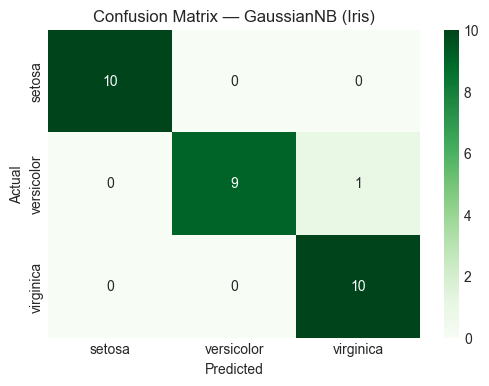

In [13]:
# ============================================================
# SECTION 10 — GAUSSIANNB ON IRIS
# ============================================================

# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Train/Test Split
X_tr_iris, X_te_iris, y_tr_iris, y_te_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, stratify=y_iris, random_state=42
)

# Initialize and Fit GaussianNB
gnb = GaussianNB()
gnb.fit(X_tr_iris, y_tr_iris)

# Predict
y_pred_iris = gnb.predict(X_te_iris)

print("--- Iris Classification Report ---")
print(classification_report(y_te_iris, y_pred_iris, target_names=iris.target_names))

# Print Learned Parameters (Means and Variances)
print("\n--- Per-Class Feature Means (theta_) ---")
df_means = pd.DataFrame(gnb.theta_, columns=iris.feature_names, index=iris.target_names)
display(df_means)

print("\n--- Per-Class Feature Variances (sigma_) ---")
df_vars = pd.DataFrame(gnb.var_, columns=iris.feature_names, index=iris.target_names)
display(df_vars)

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_te_iris, y_pred_iris), annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Confusion Matrix — GaussianNB (Iris)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 11. Tips & Tricks Summary
1. **Choose the Right Variant**: GaussianNB for continuous data, MultinomialNB for counts/TF-IDF, BernoulliNB for boolean flags, ComplementNB for imbalanced text.
2. **Handle Imbalance**: If classes are severely imbalanced, try `ComplementNB`, which corrects the biases of standard MultinomialNB.
3. **No Feature Scaling**: Do not scale data for MultinomialNB/BernoulliNB (it breaks non-negativity and discrete nature). For GaussianNB, scaling is theoretically not required but can help numerical stability.
4. **Log-Probabilities**: Always inspect `.feature_log_prob_` to understand what features the model associates most strongly with each class.
5. **Beware Zero Probabilities**: Ensure `\alpha > 0` (Laplace Smoothing) in discrete variants to avoid the zero-frequency problem.
6. **Calibration**: Naive Bayes is notorious for pushing probabilities to extremes (0 or 1). Use `calibration_curve` and consider `CalibratedClassifierCV` if you need true probabilities.
7. **Use Pipelines**: Always bundle vectorization (like TF-IDF) and the model inside a `Pipeline` to prevent data leakage during CV.
8. **Tune Alpha**: Use `GridSearchCV` to tune `\alpha` and vectorizer hyperparameters (like `ngram_range` or `max_features`) jointly.
9. **Remove Stop Words**: In text applications, removing stop words heavily improves accuracy by dropping non-discriminative high-frequency terms.
10. **Excellent Baseline**: Because it is extremely fast and robust, Naive Bayes should almost always be your first baseline model for text classification before moving to complex LLMs or deep learning.

## 12. Conclusion
Naive Bayes remains an elegant and essential algorithm in the machine learning practitioner's toolkit. By relying on a mathematically sound foundation—Bayes' Theorem—it offers tremendous speed and scalability, making it the perfect choice for high-dimensional problems like text classification and real-time spam filtering. 

Although its core assumption of feature independence is almost never perfectly true in the real world, the algorithm surprisingly thrives despite this 'naivety'. Understanding its different variants, from Gaussian to Multinomial, empowers you to leverage this classic algorithm effectively across both continuous and discrete datasets.